In [21]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (1).csv


In [22]:
import pandas as pd
df = pd.read_csv('train.csv')
print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP000001,Male,Yes,2,Graduate,No,14066,839,396.0,300.0,1.0,Semiurban,Y
1,LP000002,Female,No,0,Graduate,No,7574,2276,NaN,180.0,0.0,Semiurban,Y
2,LP000003,Female,Yes,2,Not Graduate,No,13543,569,73.0,180.0,1.0,Urban,N
3,LP000004,NaN,Yes,1,Graduate,No,6422,4562,162.0,120.0,1.0,Urban,Y
4,LP000005,Female,No,3+,Graduate,No,6040,4598,325.0,120.0,1.0,Semiurban,N


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style="whitegrid")
print("✅ Libraries loaded!")

✅ Libraries loaded!


In [24]:
df = pd.read_csv('train.csv')
print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP000001,Male,Yes,2,Graduate,No,14066,839,396.0,300.0,1.0,Semiurban,Y
1,LP000002,Female,No,0,Graduate,No,7574,2276,NaN,180.0,0.0,Semiurban,Y
2,LP000003,Female,Yes,2,Not Graduate,No,13543,569,73.0,180.0,1.0,Urban,N
3,LP000004,NaN,Yes,1,Graduate,No,6422,4562,162.0,120.0,1.0,Urban,Y
4,LP000005,Female,No,3+,Graduate,No,6040,4598,325.0,120.0,1.0,Semiurban,N


In [25]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nInfo:")
df.info()
print("\nSummary Statistics:")
df.describe()

Shape: (614, 13)

Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             581 non-null    object 
 2   Married            595 non-null    object 
 3   Dependents         578 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    int64  
 8   LoanAmount         567 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     574 non-null    float64
 11  Property_Area      614 non-null

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,567.00000,600.000000,574.000000
mean,8582.688925,2533.729642,283.27866,240.600000,0.834495
std,3805.358087,1457.894619,133.09196,83.205641,0.371960
min,2076.000000,5.000000,50.00000,120.000000,0.000000
25%,5266.750000,1180.250000,168.50000,180.000000,1.000000
50%,8420.500000,2530.500000,284.00000,240.000000,1.000000
75%,11893.000000,3859.500000,408.50000,300.000000,1.000000
max,14987.000000,4997.000000,500.00000,360.000000,1.000000


In [26]:
print("Missing values:\n")
print(df.isnull().sum())

Missing values:

Loan_ID               0
Gender               33
Married              19
Dependents           36
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           47
Loan_Amount_Term     14
Credit_History       40
Property_Area         0
Loan_Status           0
dtype: int64


In [27]:
# Fill numerical columns with median
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

# Fill categorical columns with mode (most frequent value)
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

# Confirm no more missing values
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


/tmp/ipykernel_26532/519565847.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
/tmp/ipykernel_26532/519565847.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

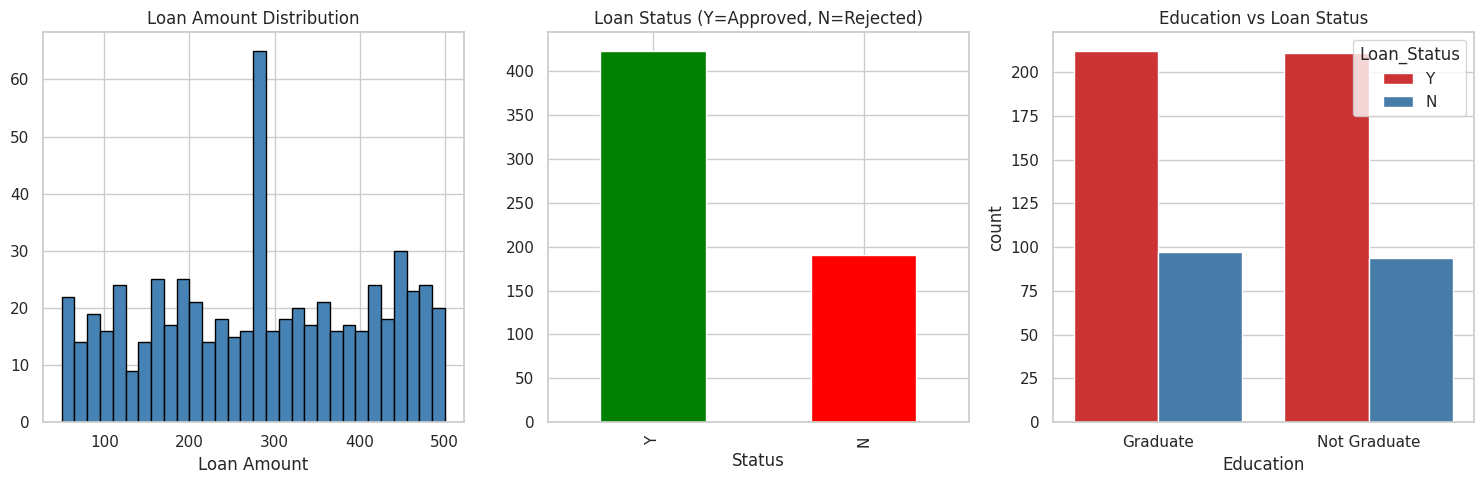

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Loan Amount Distribution
axes[0].hist(df['LoanAmount'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Loan Amount Distribution')
axes[0].set_xlabel('Loan Amount')

# Loan Status Count
df['Loan_Status'].value_counts().plot(kind='bar', ax=axes[1], color=['green', 'red'])
axes[1].set_title('Loan Status (Y=Approved, N=Rejected)')
axes[1].set_xlabel('Status')

# Education vs Loan Status
sns.countplot(data=df, x='Education', hue='Loan_Status', palette='Set1', ax=axes[2])
axes[2].set_title('Education vs Loan Status')

plt.tight_layout()
plt.show()


In [29]:
# Convert ALL text categories to numbers
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(float)
df['Property_Area'] = df['Property_Area'].map({
    'Urban': 2,
    'Semiurban': 1,
    'Rural': 0
})

print("✅ All encoding done!")
df.head()

✅ All encoding done!


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP000001,1,1,2.0,1,0,14066,839,396.0,300.0,1.0,1,1
1,LP000002,0,0,0.0,1,0,7574,2276,284.0,180.0,0.0,1,1
2,LP000003,0,1,2.0,0,0,13543,569,73.0,180.0,1.0,2,0
3,LP000004,1,1,1.0,1,0,6422,4562,162.0,120.0,1.0,2,1
4,LP000005,0,0,3.0,1,0,6040,4598,325.0,120.0,1.0,1,0


In [30]:
# Drop Loan_ID as it's not useful
df.drop(columns=['Loan_ID'], inplace=True)

# Features (X) and Target (y)
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (491, 11)
Testing size: (123, 11)


In [31]:
# Encode Property_Area column
df['Property_Area'] = df['Property_Area'].map({
    'Urban': 2,
    'Semiurban': 1,
    'Rural': 0
})

print("✅ Property_Area encoded!")
print(df['Property_Area'].value_counts())

✅ Property_Area encoded!
Series([], Name: count, dtype: int64)


In [32]:
# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

print("✅ Model trained successfully!")

✅ Model trained successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 74.80%


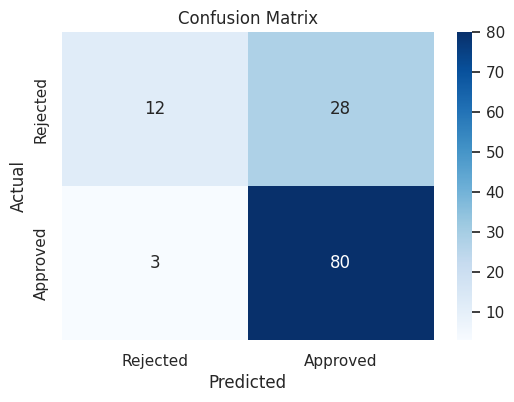


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.30      0.44        40
           1       0.74      0.96      0.84        83

    accuracy                           0.75       123
   macro avg       0.77      0.63      0.64       123
weighted avg       0.76      0.75      0.71       123



In [33]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

## Conclusion
- Dataset had missing values which were handled using median and mode
- Graduates have higher loan approval rates than non-graduates
- Credit history is the strongest factor in loan approval
- Logistic Regression achieved 74.80% accuracy
- Model predicts approvals well but needs improvement on rejections